## Pairwise read distance check

For a random selection of sequenced samples (from `setup/strain_layout_20260630.csv`, fastqs in the `demux/unflipped/` folder), pick one random read per sample and plot the histogram of edit distances from that reference read to every other read assigned to the sample.

Each well is a **pair** of strains, so we hope to see a **bimodal** distribution: a low-distance peak (reads of the same strain as the reference, differing only by ONT sequencing error) and a high-distance peak (reads from the other strain in the well).

In [1]:
from pathlib import Path
import gzip
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import edlib
from Bio import SeqIO

# ---- config ----------------------------------------------------------------
BASE = Path("/home/rl/scripts/karl/pairwise_interaction_experiments/20260630")
LAYOUT_CSV = BASE / "setup" / "strain_layout_20260630.csv"
DEMUX_DIR = BASE / "demux" / "unflipped"   # per-sample demultiplexed fastqs

N_SAMPLES = 20        # how many random samples to visualize
MIN_READS = 15        # only pick samples with at least this many reads
MAX_READS = 300       # cap reads used per sample (keeps it fast)
SEED = 0              # set to None for a fresh random pick each run

rng = random.Random(SEED)


def sample_fastq_path(plate, well):
    """demux fastqs are named Plate{plate:02d}_{well}.fastq (uncompressed or .gz)."""
    stem = f"Plate{int(plate):02d}_{well}"
    for name in (f"{stem}.fastq", f"{stem}.fastq.gz"):
        p = DEMUX_DIR / name
        if p.exists():
            return p
    return None


def load_reads(path, max_reads=MAX_READS):
    """Return list of read sequences (uppercase str) from a fastq(.gz)."""
    opener = gzip.open if str(path).endswith(".gz") else open
    seqs = []
    with opener(path, "rt") as fh:
        for rec in SeqIO.parse(fh, "fastq"):
            seqs.append(str(rec.seq).upper())
    if len(seqs) > max_reads:
        seqs = rng.sample(seqs, max_reads)
    return seqs


def distances_to_reference(seqs, ref_idx):
    """Normalized edit distance (edits / longer length) from seqs[ref_idx] to every read."""
    ref = seqs[ref_idx]
    dists = []
    for s in seqs:
        ed = edlib.align(ref, s, mode="NW", task="distance")["editDistance"]
        dists.append(ed / max(len(ref), len(s)))
    return np.array(dists)


In [2]:
# ---- pick N random samples that actually have enough reads -----------------
layout = pd.read_csv(LAYOUT_CSV)

# build the full list of samples with a resolvable fastq path
candidates = []
for _, r in layout.iterrows():
    path = sample_fastq_path(r["dest_plate"], r["dest_well"])
    if path is not None:
        candidates.append({
            "sample_id": f"Plate{int(r['dest_plate']):02d}_{r['dest_well']}",
            "path": path,
            "well_type": r.get("well_type"),
            "strain1": r.get("strain1"),
            "strain2": r.get("strain2"),
        })

# shuffle, then keep the first N whose read count clears MIN_READS
rng.shuffle(candidates)
chosen = []
for c in candidates:
    seqs = load_reads(c["path"])
    if len(seqs) >= MIN_READS:
        c["seqs"] = seqs
        chosen.append(c)
    if len(chosen) == N_SAMPLES:
        break

print(f"selected {len(chosen)} samples (>= {MIN_READS} reads each):")
for c in chosen:
    print(f"  {c['sample_id']:14s}  n={len(c['seqs']):3d}  "
          f"{c['well_type']}  {c['strain1']} + {c['strain2']}")


selected 20 samples (>= 15 reads each):
  Plate01_H17     n= 61  pair  P17 + E8
  Plate13_D3      n= 48  pair  A15 + G8
  Plate03_H16     n= 55  pair  E9 + P21
  Plate19_N23     n= 43  pair  J5 + M13
  Plate17_D19     n= 29  pair  M13 + P21
  Plate05_H6      n= 42  pair  F7 + G8
  Plate17_N8      n= 54  pair  H17 + E8
  Plate05_M16     n= 41  pair  H11 + E24
  Plate05_H20     n= 35  pair  A21 + G17
  Plate15_D12     n= 18  pair  J9 + G11
  Plate09_E18     n= 61  pair  P19 + G4
  Plate11_I21     n= 30  pair  P11 + F13
  Plate05_O23     n= 44  pair  G21 + P21
  Plate15_E14     n= 67  pair  G5 + F7
  Plate01_F23     n= 51  pair  M9 + G11
  Plate13_E8      n= 51  pair  P11 + E24
  Plate07_N15     n= 42  pair  G18 + O15
  Plate09_D8      n= 36  pair  G17 + E9
  Plate13_K5      n= 60  pair  E21 + E7
  Plate15_D11     n= 30  pair  O7 + A2


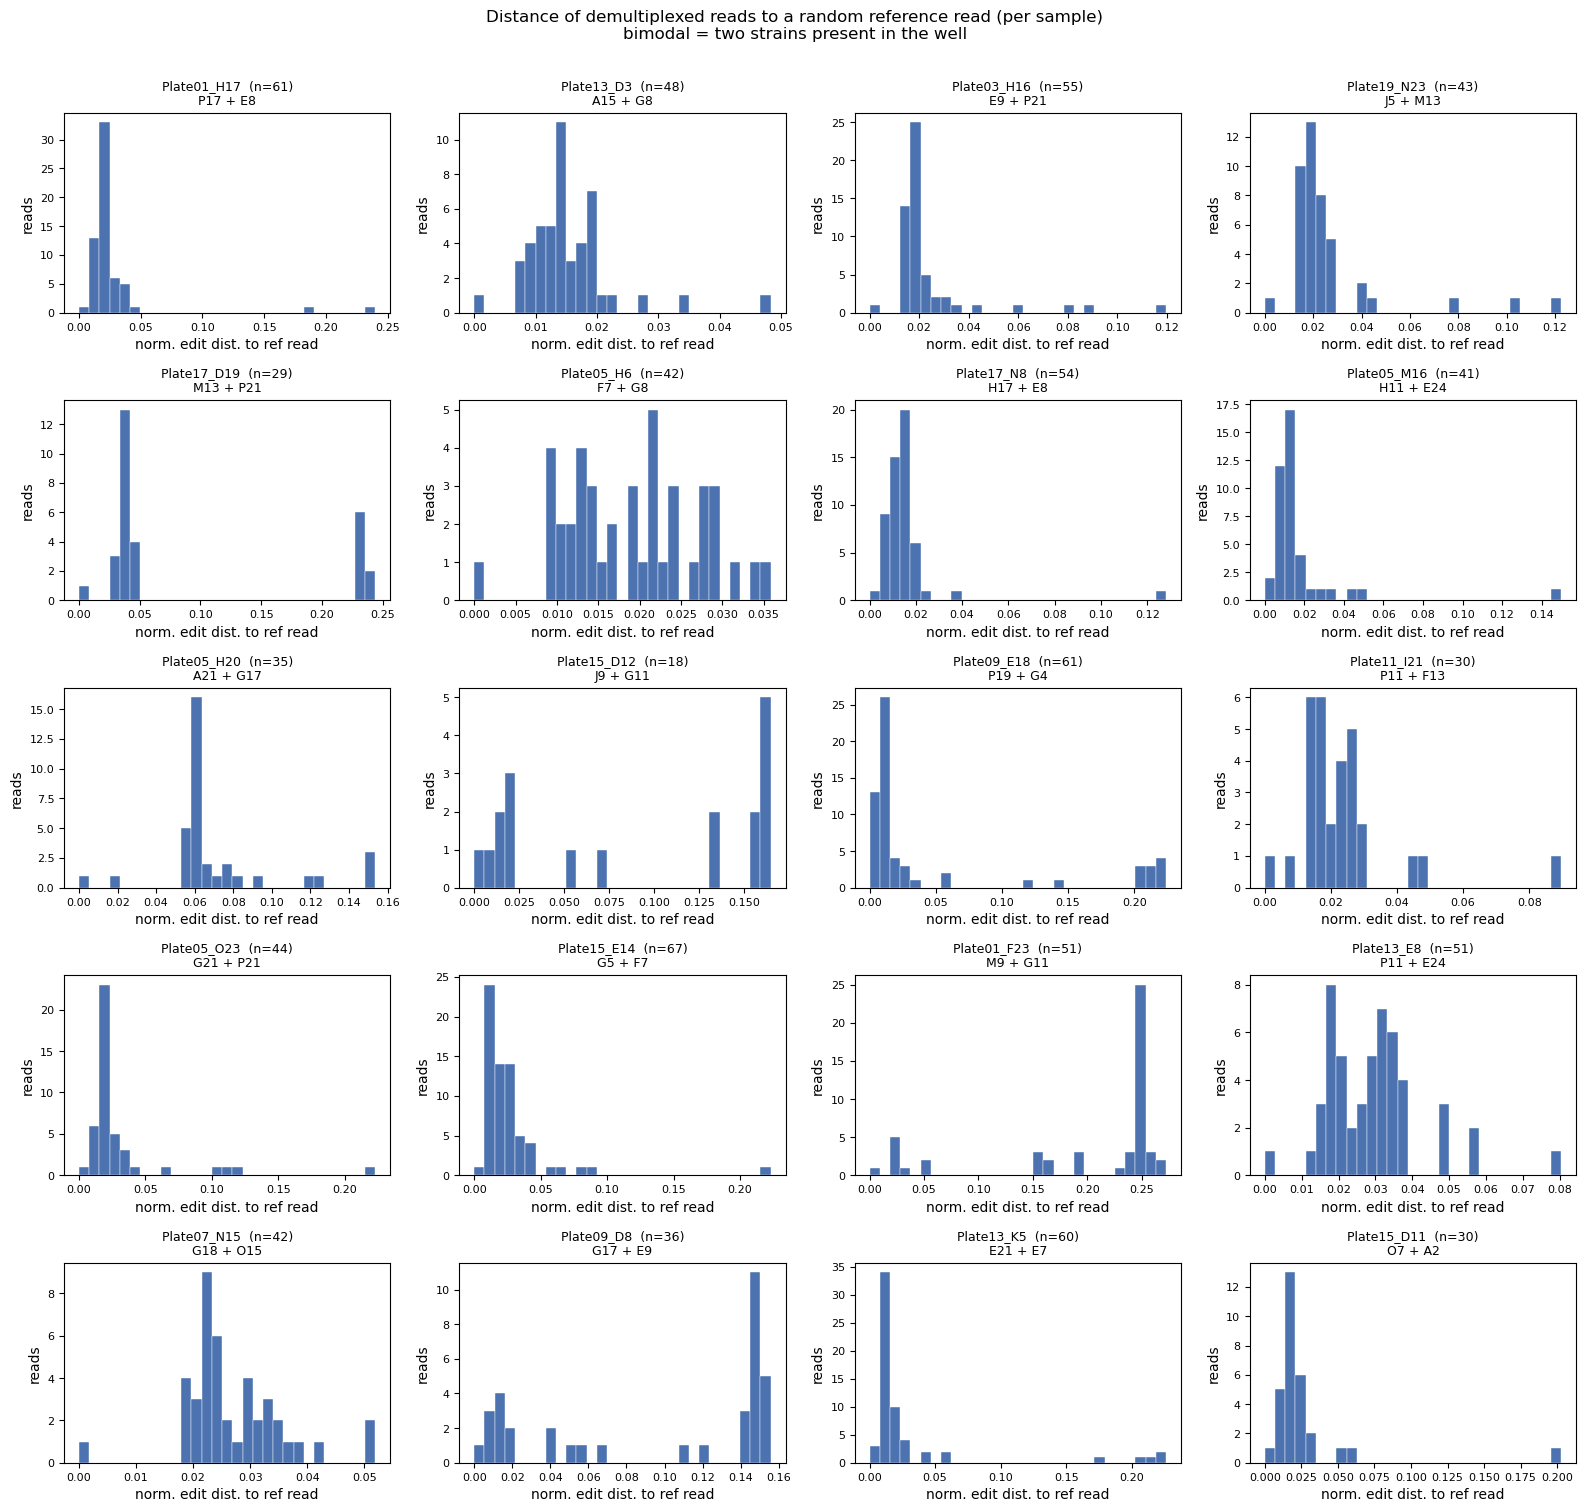

In [3]:
# ---- one random reference read per sample, histogram of distances ----------
ncols = 4
nrows = int(np.ceil(len(chosen) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, c in zip(axes, chosen):
    seqs = c["seqs"]
    ref_idx = rng.randrange(len(seqs))       # random reference read
    dists = distances_to_reference(seqs, ref_idx)

    ax.hist(dists, bins=np.linspace(0, dists.max() + 1e-6, 30),
            color="#4C72B0", edgecolor="white", linewidth=0.3)
    ax.set_title(f"{c['sample_id']}  (n={len(seqs)})\n{c['strain1']} + {c['strain2']}",
                 fontsize=9)
    ax.set_xlabel("norm. edit dist. to ref read")
    ax.set_ylabel("reads")
    ax.tick_params(labelsize=8)

# hide any unused axes
for ax in axes[len(chosen):]:
    ax.axis("off")

fig.suptitle("Distance of demultiplexed reads to a random reference read (per sample)\n"
             "bimodal = two strains present in the well", fontsize=12, y=1.005)
fig.tight_layout()
plt.show()
